# Feature Importance Analysis

This notebook demonstrates how to determine feature importance for ALL features in the dataset using SHAP values and permutation importance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance

import sys
import os
import re
sys.path.append(os.path.abspath('..'))
from src.xgb_model import xgb_model_pipeline


c:\Users\sbout\Documents\school\URI\capstone\covid-housing-forecast\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Load the dataset
data_path = '../data/processed/processed_data_pre_model.csv'
df = pd.read_csv(data_path)

# Clean column names for XGBoost (which throws errors on special characters like [ , < , ])
df.columns = [re.sub(r'[<>\[\]]', '', col) for col in df.columns]

# Define parameters for the model
target_col = 'median_listing_price_x'
params = {
    'n_estimators': 100,
    'max_depth': 6,
    'learning_rate': 0.1,
    'random_state': 42
}

# Pre-filter to a state level for Florida
#level = 'state'
#state = 'fl'
level = 'us'

# --- PRE-PROCESSING TO AVOID NAN DROPS ---
# When including all columns, any row with a single NaN in ANY column is dropped by the pipeline.
# To prevent dropping all data, we pre-filter and impute.
# We filter exactly to our state to do clean imputations
#if 'state' in df.columns:
 #   df_state = df[df['state'].astype(str).str.lower() == state.lower()].copy()
#else:
#    df_state = df.copy()

df_state = df.copy()

# Drop highly empty columns (>30% missing for Florida)
df_state = df_state.dropna(thresh=len(df_state) * 0.7, axis=1)

# Forward and backward fill remaining gaps in numeric columns to ensure time-series integrity
numeric_cols = df_state.select_dtypes(include=['number']).columns
df_state[numeric_cols] = df_state[numeric_cols].ffill().bfill()

# Include all surviving columns for the pipeline to test
selected_cols = df_state.columns.tolist()

print(f"Testing {len(selected_cols)} features...")
print("Running XGBoost Pipeline...")
results = xgb_model_pipeline(
    target_col=target_col,
    dataset=df_state,
    selected_cols=selected_cols,
    params=params,
    level=level,
    #state=state
)

model = results['model']
X_train = results['X_train']
X_test = results['X_test']
y_test = results['y_test']
print("Model trained.")


C:\Users\sbout\AppData\Local\Temp\ipykernel_25132\3246694686.py:3: DtypeWarning: Columns (46,48) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


Testing 50 features...
Running XGBoost Pipeline...


c:\Users\sbout\Documents\school\URI\capstone\covid-housing-forecast\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:56:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\sbout\Documents\school\URI\capstone\covid-housing-forecast\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:56:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\sbout\Documents\school\URI\capstone\covid-housing-forecast\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:56:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\sbout\Documents\school\URI\capstone\covid-housin

Model trained.


## SHAP Summary Plot
SHAP (SHapley Additive exPlanations) is a game theoretic approach to explain the output of any machine learning model.

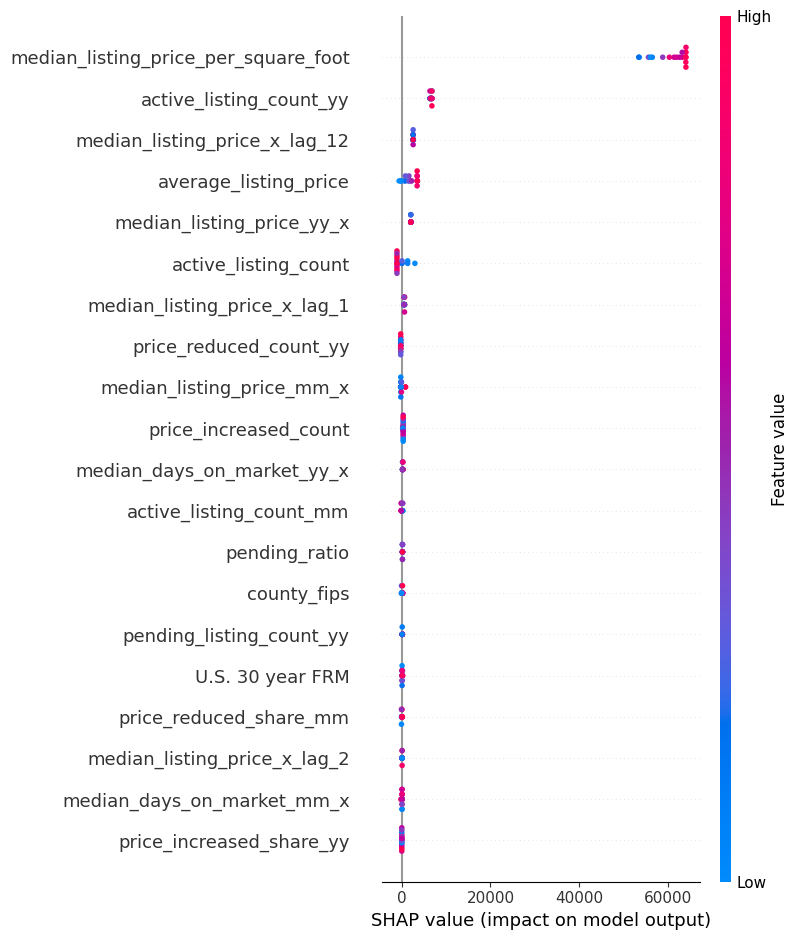

In [6]:
# Initialize SHAP Explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Create the summary plot
shap.summary_plot(shap_values, X_test, max_display=20)


## Permutation Importance
Permutation feature importance measures the increase in the prediction error of the model after we permuted the feature's values.

C:\Users\sbout\AppData\Local\Temp\ipykernel_25132\3755063626.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(perm_importance.importances[sorted_idx].T, vert=False, labels=X_test.columns[sorted_idx])


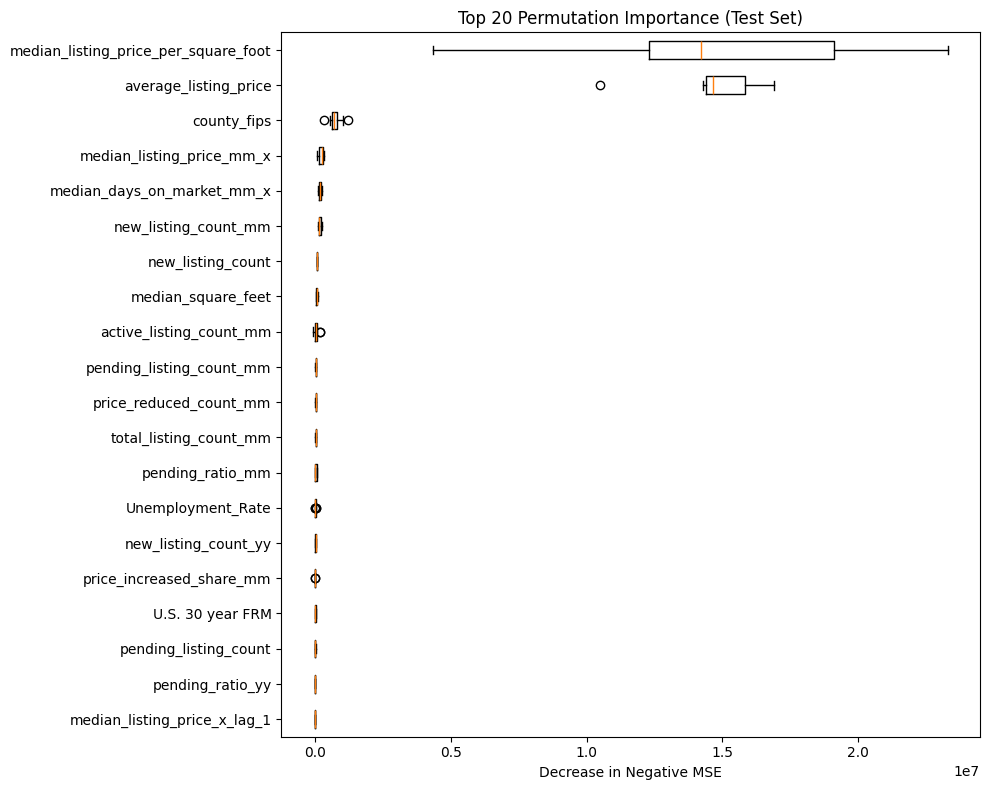

In [7]:
# Calculate permutation importance on the test set
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, scoring='neg_mean_squared_error')

# We only plot the top 20 most important features
sorted_idx = perm_importance.importances_mean.argsort()[-20:]

plt.figure(figsize=(10, 8))
plt.boxplot(perm_importance.importances[sorted_idx].T, vert=False, labels=X_test.columns[sorted_idx])
plt.title("Top 20 Permutation Importance (Test Set)")
plt.xlabel("Decrease in Negative MSE")
plt.tight_layout()
plt.show()
